# Adding a new scheme

A **scheme** owns the *iteration policy*: how many steps to take, whether to
accept or reject one, how to damp, and when to stop. The per-iteration
mathematics belongs to the analysis instead — see
[Adding a new analysis](adding_an_analysis.ipynb).

Roughly:

| | owns |
| --- | --- |
| analysis | one step: ensemble + predictions -> update |
| scheme | the loop around it: accept/reject, damping, stopping |
| ensemble | the data: state realisations, observations, simulator |

## What you inherit

Concrete schemes subclass `AssimilationScheme`, which combines the algorithm
core with the run workflow (artifact saving, diagnostics, outlier handling):

In [1]:
from pipt.update_schemes.core.workflow import AssimilationScheme

for c in AssimilationScheme.__mro__:
    print("   ", c.__name__)

    AssimilationScheme
    AssimilationWorkflowMixin
    AssimilationSchemeBase
    AnalysisBindingMixin
    RestartMixin
    ABC
    object


That single base gives you the iteration loop, convergence bookkeeping,
restart handling, the result object, analysis binding, and the ensemble
façade. The order matters and is easy to get wrong by hand, which is why the
combination is made once here rather than in every scheme.

### The one required method

```python
def update_step(self) -> bool
```

Perform one attempt and report whether it was **accepted**. Returning `False`
means the loop retries at the same iteration number instead of advancing —
that is how the Levenberg-Marquardt family backs off.

### Optional hooks

| hook | default | use it to |
| --- | --- | --- |
| `check_convergence()` | `False` | stop on your own criterion |
| `score_prior()` | – | score the iteration-0 forecast |
| `after_forecast()` | – | act between forecast and scoring |
| `after_accepted_iteration()` | – | act once a step is kept |
The base deliberately stops there. It calls `update_step()` and nothing
inside it: how a scheme performs its step is the scheme's business. So there
is no `after_analysis` hook on the base -- that point exists only inside
`update_step()`. `AssimilationWorkflowMixin` declares and implements one for
the schemes that inherit `AssimilationScheme`, and a scheme calls it from its
own step, as the example below does.


## The façade rule

Reads of ensemble state go through the scheme; **writes go to the ensemble
explicitly**:

```python
x = self.enX                      # read  -- a property on the scheme
self.ensemble.enX_temp = x + step # write -- the forecast reads this back
```

A read-only property has no setter, so a stray `self.enX = ...` raises rather
than silently creating a copy the forecast never sees. Four names are the
exception and *do* have setters, because a scheme may legitimately compute
them itself: `cov_data`, `scale_data`, `proj`, `Am`.

## A worked example

A smoother that takes a fixed fraction of each analysis step and never
rejects — simpler than LM-EnRML, but a complete scheme.

In [2]:
from copy import deepcopy
import numpy as np
import pipt.misc_tools.analysis_tools as at
from geostat.decomp import Cholesky
from pipt.ensembles import AssimilationEnsemble
from pipt.update_schemes.core.workflow import AssimilationScheme
from pipt.update_schemes.analysis.approx import approx_update


class FixedStepSmoother(AssimilationScheme):
    """Iterative smoother taking a fixed fraction of each analysis step."""

    ENSEMBLE_CLASS = AssimilationEnsemble
    COMPATIBLE_ANALYSES = {"approx": approx_update}

    def __init__(self, keys_da, keys_en, sim, analysis=None):
        ensemble = self.ENSEMBLE_CLASS(keys_da, keys_en, sim)
        # Zero tolerances switch off the generic criteria; this scheme decides
        # for itself in check_convergence().
        super().__init__(ensemble, misfit_tol=0.0, step_tol=0.0)
        self.bind_analysis(self.resolve_analysis(analysis, keys_da))

        opts = self.keys_da.get("iteration", {})
        self.maxiter      = opts.get("max_iter", 5)
        self.gamma        = opts.get("gamma", 0.5)   # fixed step length
        self.lam          = 0.0                      # analyses expect this
        self.trunc_energy = self.keys_da.get("energy", 0.98)
        self.iteration    = self.ensemble.iteration = 0
        self.prev_data_misfit = None

        # The ensemble does not build these; the scheme owns them.
        self.ensemble.prior_enX      = deepcopy(self.enX)
        self.ensemble.list_states    = list(self.enX.indices)
        self.ensemble.list_datatypes = self.keys_da["datatype"]
        self.vecObs   = self.data_df.to_matrix()
        self.cov_data = at.construct_data_cov(self.data_var_df)

    def calc_analysis(self):
        """Draw perturbed observations, ask the analysis for a step, apply it."""
        self.enPred = self.pred_data.to_matrix()
        self.enObs, self.scale_data = Cholesky().gen_real(
            self.vecObs, self.cov_data, self.ne, return_chol=True)
        self.E = np.dot(self.enObs, self.proj)

        step = self.update(enX=self.enX, enY=self.enPred, enE=self.enObs)
        if step is not None:
            # Written to the ensemble: the forecast reads enX_temp back.
            self.ensemble.enX_temp = self.enX + self.gamma * step

    def score_and_commit(self):
        """Score the forecast that followed the analysis, then keep the state."""
        self.prev_data_misfit = self.data_misfit
        misfit = at.calc_objectivefun(self.enObs, self.pred_data.to_matrix(),
                                      self.cov_data)
        self.data_misfit, self.data_misfit_std = np.mean(misfit), np.std(misfit)
        self.ensemble_misfit = misfit
        if self.prior_data_misfit is None:
            self.prior_data_misfit = self.data_misfit

        self.ensemble.enX = deepcopy(self.enX_temp)
        self.ensemble.enX_temp = None

    def update_step(self) -> bool:
        self.calc_analysis()
        self.after_analysis()
        self.run_forecast()
        self.score_and_commit()
        return True          # this scheme never rejects

    def check_convergence(self) -> bool:
        return False         # run the full schedule

print("defined", FixedStepSmoother.__name__)

defined FixedStepSmoother


## A case to run it on

In [3]:
import os, tempfile
from copy import deepcopy
import numpy as np
from misc.structures import PETDataFrame
from simulator.simple_models import lin_1d

# A 60-cell state observed at every 5th position. Pure numpy, runs instantly.
STATE_SIZE = 60
CFG_SIM = {"reporttype": "position", "reportpoint": list(range(5, STATE_SIZE, 5)),
           "datatype": ["value"],
           # NOTE: >1 is deliberate. lin_1d returns a shared internal object from
           # run_fwd_sim, so a sequential run aliases every member onto the same
           # prediction and the ensemble collapses to zero spread.
           "parallel": 4}

CFG_ENS = {"ne": 50, "state": "x",
           "prior_x": {"vario": "sph", "mean": [0.0] * STATE_SIZE, "var": 1.0,
                       "range": 20.0, "aniso": 1.0, "angle": 0.0,
                       "grid": [STATE_SIZE, 1]}}

def cfg_da(analysis, **iteration):
    it = {"max_iter": 6, "data_misfit_tol": 1e-3, "lambda": 5.0,
          "lambda_factor": 4.0, "lambda_max": 1e8}
    it.update(iteration)
    return {"scheme": "custom", "analysis": analysis, "energy": 0.95,
            "obsname": "position", "data": "true_data.pkl", "datavar": "var.pkl",
            "iteration": it}

def make_truth():
    """Write the synthetic observations the schemes below assimilate.

    Returns the true state, so the plots can compare against it.
    """
    np.random.seed(10)
    sim = lin_1d(CFG_SIM); sim.setup_fwd_run()
    state = {"x": np.random.multivariate_normal(np.zeros(STATE_SIZE), np.eye(STATE_SIZE))}
    pred = PETDataFrame.from_records(sim.run_fwd_sim(state, 0), index=CFG_SIM["reportpoint"])
    data, var = pred.copy(), pred.copy()
    for c in data.columns:
        data[c] = data[c].apply(np.squeeze)
        var[c] = var[c].apply(lambda _: ["abs", 1.0])
    data.to_pickle("true_data.pkl"); var.to_pickle("var.pkl")
    return state["x"]

os.chdir(tempfile.mkdtemp())   # keep run artifacts out of the docs tree
TRUE_STATE = make_truth()
OBS_AT = CFG_SIM["reportpoint"]
print(f"case ready: {STATE_SIZE}-cell state, {len(OBS_AT)} observations, ne={CFG_ENS['ne']}")

case ready: 60-cell state, 11 observations, ne=50


In [4]:
np.random.seed(10)
res = FixedStepSmoother.assimilate(cfg_da("approx"), deepcopy(CFG_ENS),
                                   lin_1d(CFG_SIM), analysis="approx")
print(f"misfit {res.prior_data_misfit:7.2f} -> {res.data_misfit:6.2f}"
      f"   iterations={res.nit}")
print("stopped because:", res.message)

2026-08-24│12:43:03 :  =========== Running Data Assimilation - CUSTOM ===========


  0%|                                                                              | 0/50 [00:00<?, ?member/s]

  0%|                                                                              | 0/50 [00:00<?, ?member/s]

  0%|                                                                              | 0/50 [00:00<?, ?member/s]

  0%|                                                                              | 0/50 [00:00<?, ?member/s]

...

  0%|                                                                              | 0/50 [00:00<?, ?member/s]

2026-08-24│12:43:04 : Maximum iterations reached without convergence.


2026-08-24│12:43:04 :  
 Convergence was met. Obj. function reduced from 20.1 to 12.4


2026-08-24│12:43:04 :  Assimilation finished after 6 iteration(s): Maximum number of iterations reached


misfit   20.08 ->  12.42   iterations=6
stopped because: Maximum number of iterations reached


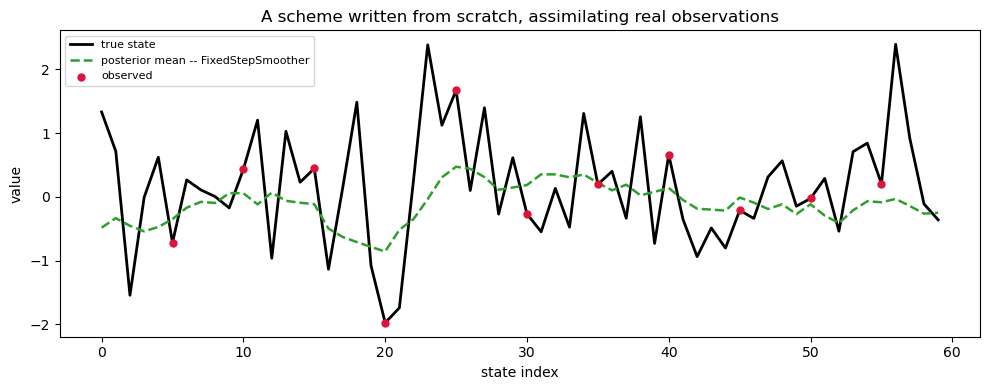

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(TRUE_STATE, "k-", lw=2, label="true state")
ax.plot(np.asarray(res.x).mean(axis=-1), "--", lw=1.8, c="tab:green",
        label="posterior mean -- FixedStepSmoother")
ax.scatter(OBS_AT, TRUE_STATE[OBS_AT], c="crimson", zorder=5, s=25, label="observed")
ax.set_xlabel("state index"); ax.set_ylabel("value")
ax.set_title("A scheme written from scratch, assimilating real observations")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## Making it available from a config

The class works directly, as above. To reach it the way the built-in schemes
are reached — by name from a config's `scheme` / `analysis` keys — register
the combination:

In [6]:
from pipt.update_schemes import registry

registry.register_scheme("fixedstep", "approx", FixedStepSmoother, overwrite=True)

ctor = registry.get_scheme("fixedstep", "approx")
print("registry resolves to:", ctor.func.__name__ if hasattr(ctor, "func") else ctor)
print("('fixedstep', 'approx') in available_schemes():",
      ("fixedstep", "approx") in registry.available_schemes())

registry resolves to: <class '__main__.FixedStepSmoother'>
('fixedstep', 'approx') in available_schemes(): True


## Checklist

1. Subclass `AssimilationScheme`.
2. Set `ENSEMBLE_CLASS` and `COMPATIBLE_ANALYSES`.
3. In `__init__`: build the ensemble, call `super().__init__(...)`, then
   `bind_analysis(resolve_analysis(...))`. Set anything the analyses expect
   (`lam`, `trunc_energy`) and anything the ensemble does not build for you
   (`cov_data`, the observation vector).
4. Implement `update_step()`; return `False` for a rejected attempt.
5. Read state through the scheme, write it through `self.ensemble`.
6. Override `check_convergence()` if the scheme stops on its own criterion,
   and set `self.conv_msg` when it does — otherwise the run reports no
   stopping reason.
7. `register_scheme(...)` if it should be reachable from a config.